FileNotFoundError: [Errno 2] No such file or directory: '../outputs/charts/Portfolio_Market_Value_by_Sector.png'

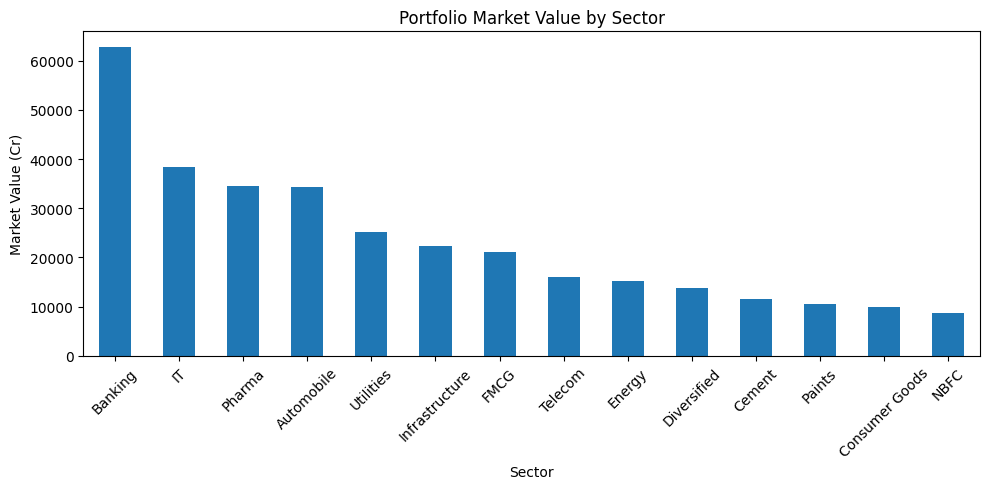

In [30]:
sector_data = portfolio.groupby('sector')['market_value_cr'].sum().sort_values(ascending=False)

plt.figure(figsize=(10,5))
sector_data.plot(kind='bar')
plt.title('Portfolio Market Value by Sector')
plt.xlabel('Sector')
plt.ylabel('Market Value (Cr)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("../outputs/charts/Portfolio_Market_Value_by_Sector.png",bbox_inches="tight")
plt.show()

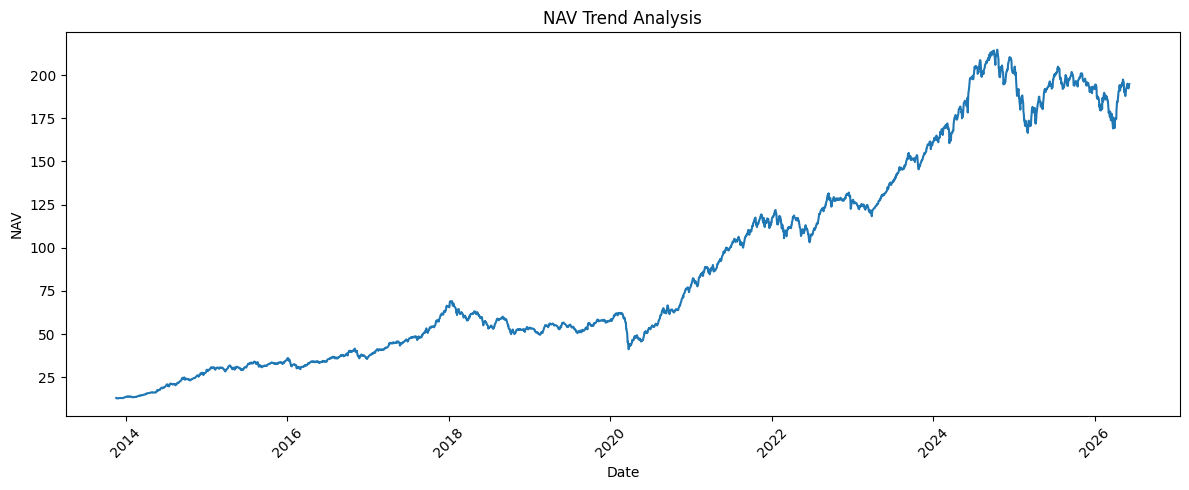

In [26]:
nav_data = pd.read_csv('../data/raw/live_nav_125497.csv')

nav_data['date'] = pd.to_datetime(nav_data['date'], dayfirst=True)

plt.figure(figsize=(12,5))
plt.plot(nav_data['date'], nav_data['nav'])

plt.title('NAV Trend Analysis')
plt.xlabel('Date')
plt.ylabel('NAV')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

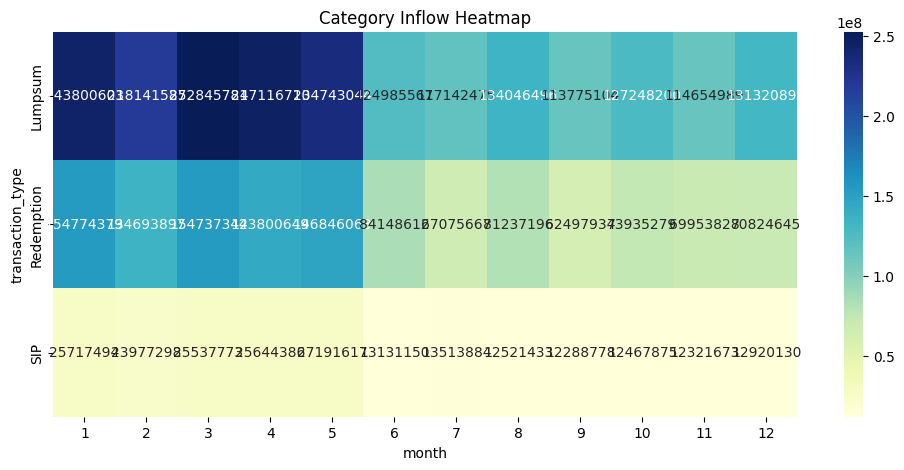

In [24]:
investor_txn['month'] = investor_txn['transaction_date'].dt.month

heatmap_data = pd.pivot_table(
    investor_txn,
    values='amount_inr',
    index='transaction_type',
    columns='month',
    aggfunc='sum'
)

plt.figure(figsize=(12,5))
sns.heatmap(heatmap_data, annot=True, fmt='.0f', cmap='YlGnBu')
plt.title('Category Inflow Heatmap')
plt.show()

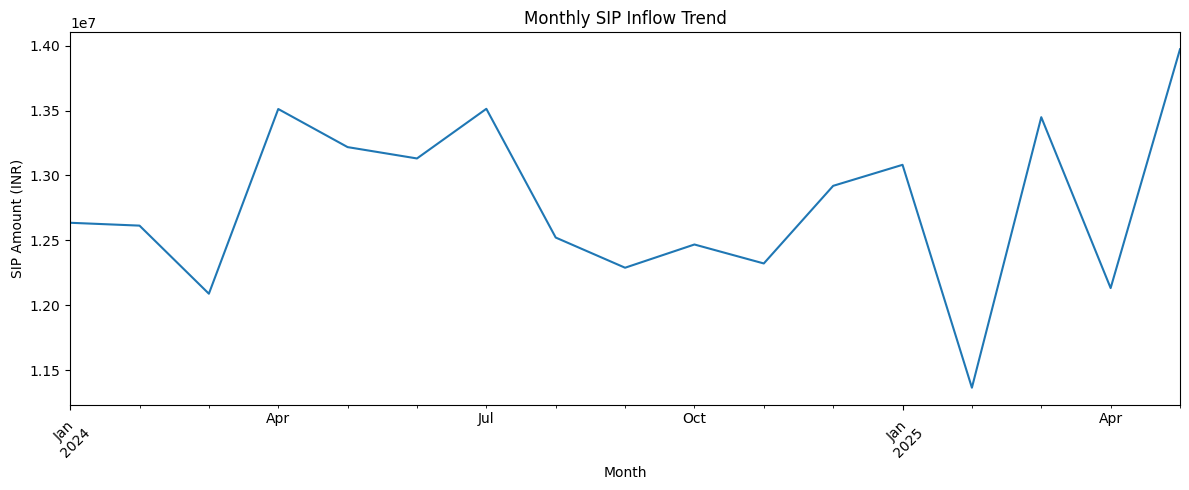

In [23]:
investor_txn['transaction_date'] = pd.to_datetime(investor_txn['transaction_date'],dayfirst=True)

sip_data = investor_txn[
    investor_txn['transaction_type'] == 'SIP'
].copy()

sip_data['month'] = sip_data['transaction_date'].dt.to_period('M')

monthly_sip = sip_data.groupby('month')['amount_inr'].sum()

plt.figure(figsize=(12,5))
monthly_sip.plot()
plt.title('Monthly SIP Inflow Trend')
plt.xlabel('Month')
plt.ylabel('SIP Amount (INR)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

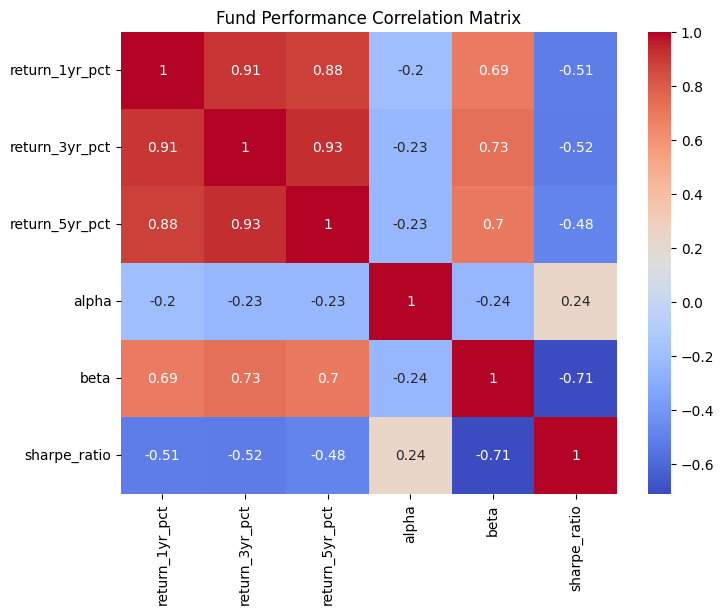

In [21]:
corr_cols = [
    'return_1yr_pct',
    'return_3yr_pct',
    'return_5yr_pct',
    'alpha',
    'beta',
    'sharpe_ratio'
]

corr_matrix = scheme_perf[corr_cols].corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title("Fund Performance Correlation Matrix")
plt.show()

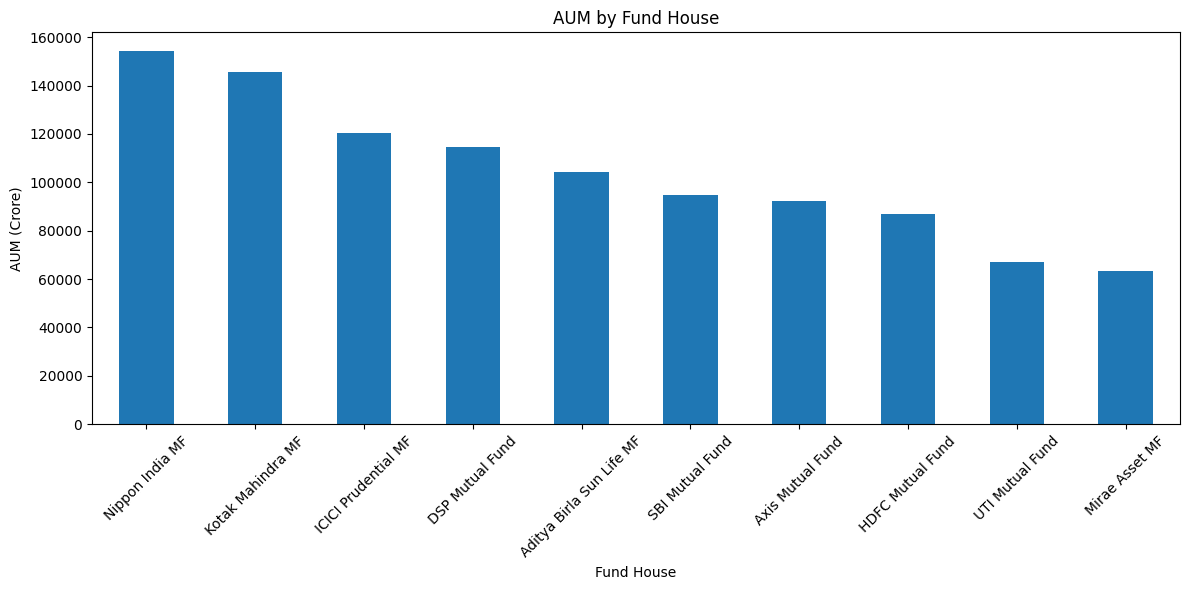

In [20]:
aum_data = scheme_perf.groupby('fund_house')['aum_crore'].sum().sort_values(ascending=False)

plt.figure(figsize=(12,6))
aum_data.plot(kind='bar')
plt.title('AUM by Fund House')
plt.xlabel('Fund House')
plt.ylabel('AUM (Crore)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

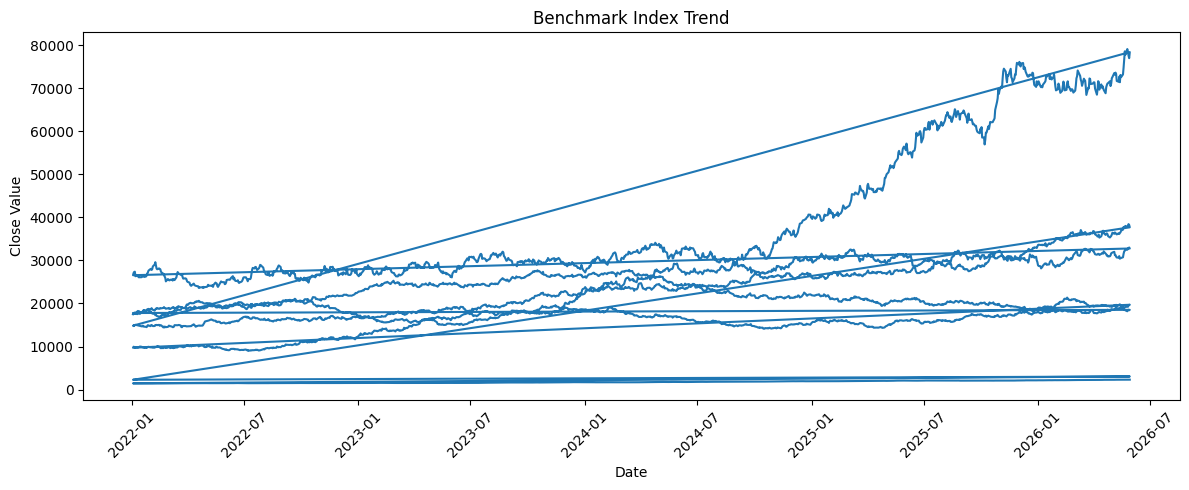

In [19]:
# Benchmark Trend Analysis

benchmark['date'] = pd.to_datetime(benchmark['date'])

plt.figure(figsize=(12,5))
plt.plot(benchmark['date'], benchmark['close_value'])
plt.title('Benchmark Index Trend')
plt.xlabel('Date')
plt.ylabel('Close Value')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [18]:
print("SCHEME PERFORMANCE")
print(scheme_perf.columns.tolist())

print("\nINVESTOR TRANSACTIONS")
print(investor_txn.columns.tolist())

print("\nPORTFOLIO")
print(portfolio.columns.tolist())

print("\nBENCHMARK")
print(benchmark.columns.tolist())

SCHEME PERFORMANCE
['amfi_code', 'scheme_name', 'fund_house', 'category', 'plan', 'return_1yr_pct', 'return_3yr_pct', 'return_5yr_pct', 'benchmark_3yr_pct', 'alpha', 'beta', 'sharpe_ratio', 'sortino_ratio', 'std_dev_ann_pct', 'max_drawdown_pct', 'aum_crore', 'expense_ratio_pct', 'morningstar_rating', 'risk_grade']

INVESTOR TRANSACTIONS
['investor_id', 'transaction_date', 'amfi_code', 'transaction_type', 'amount_inr', 'state', 'city', 'city_tier', 'age_group', 'gender', 'annual_income_lakh', 'payment_mode', 'kyc_status']

PORTFOLIO
['amfi_code', 'stock_symbol', 'stock_name', 'sector', 'weight_pct', 'market_value_cr', 'current_price_inr', 'portfolio_date']

BENCHMARK
['date', 'index_name', 'close_value']


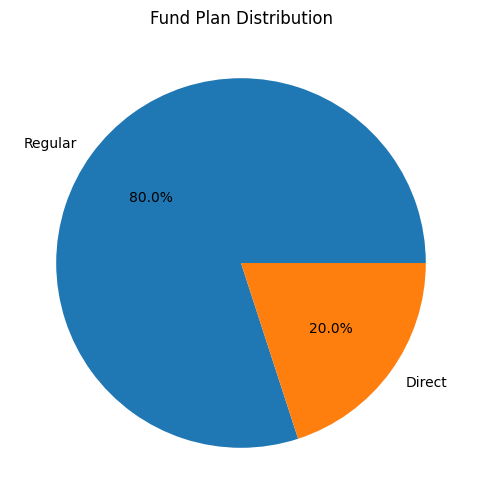

In [17]:
plan_data = scheme_perf["plan"].value_counts()

plt.figure(figsize=(6,6))
plan_data.plot(kind="pie", autopct="%1.1f%%")
plt.title("Fund Plan Distribution")
plt.ylabel("")
plt.show()

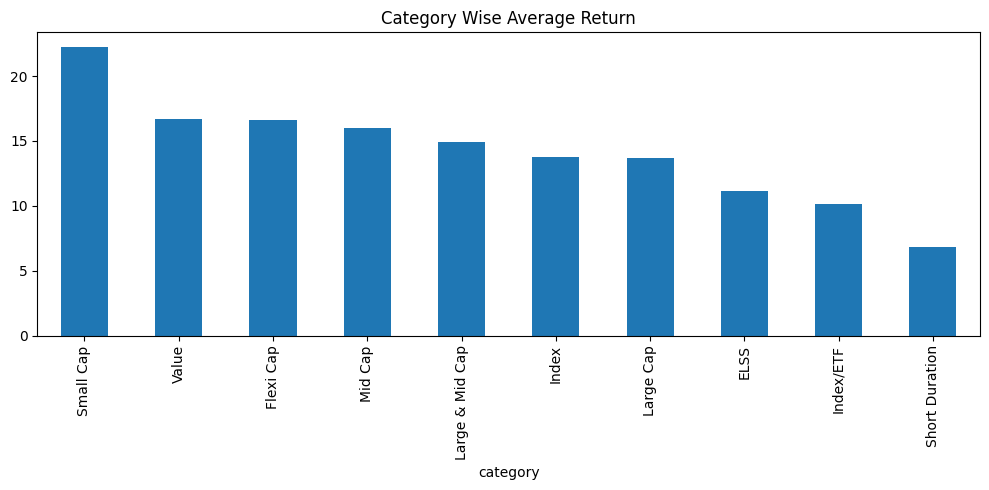

In [16]:
cat_return = scheme_perf.groupby(
    "category"
)["return_1yr_pct"].mean().sort_values(
    ascending=False
).head(10)

plt.figure(figsize=(10,5))
cat_return.plot(kind="bar")
plt.title("Category Wise Average Return")
plt.tight_layout()
plt.show()

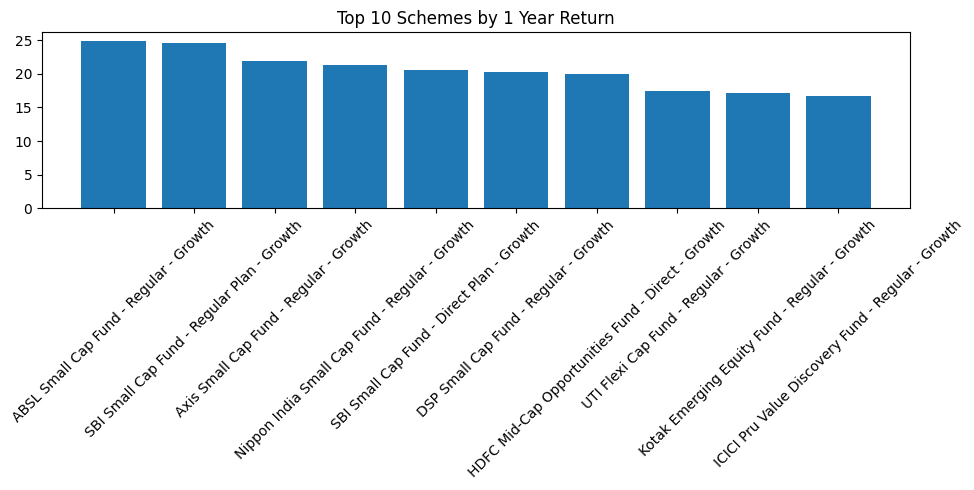

In [15]:
top_return = scheme_perf.sort_values(
    "return_1yr_pct",
    ascending=False
).head(10)

plt.figure(figsize=(10,5))
plt.bar(top_return["scheme_name"],
        top_return["return_1yr_pct"])
plt.xticks(rotation=45)
plt.title("Top 10 Schemes by 1 Year Return")
plt.tight_layout()
plt.show()

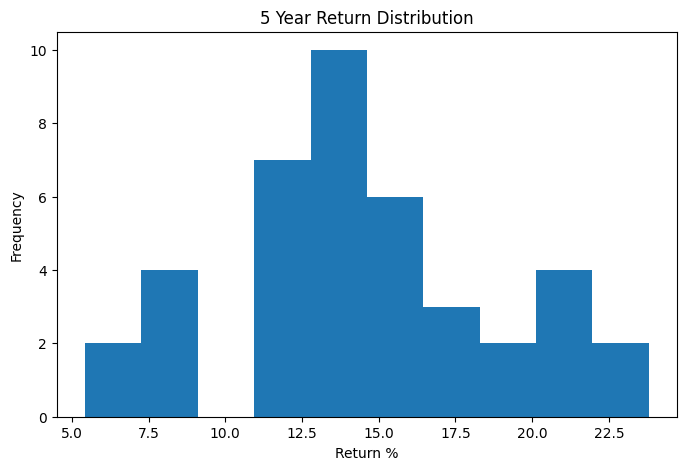

In [14]:
plt.figure(figsize=(8,5))
plt.hist(scheme_perf["return_5yr_pct"], bins=10)
plt.title("5 Year Return Distribution")
plt.xlabel("Return %")
plt.ylabel("Frequency")
plt.show()

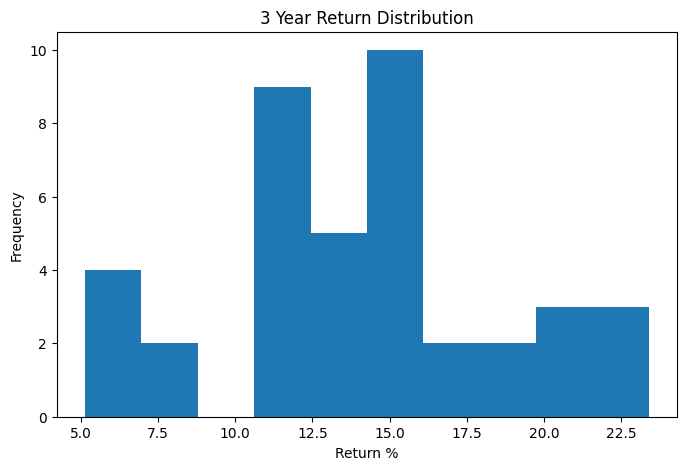

In [13]:
plt.figure(figsize=(8,5))
plt.hist(scheme_perf["return_3yr_pct"], bins=10)
plt.title("3 Year Return Distribution")
plt.xlabel("Return %")
plt.ylabel("Frequency")
plt.show()

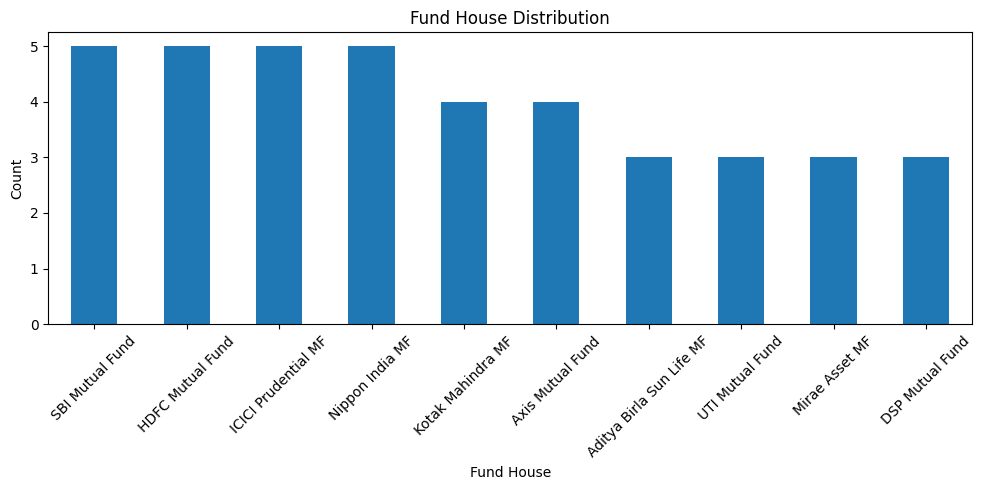

In [12]:
fund_house = scheme_perf["fund_house"].value_counts().head(10)

plt.figure(figsize=(10,5))
fund_house.plot(kind="bar")
plt.title("Fund House Distribution")
plt.xlabel("Fund House")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

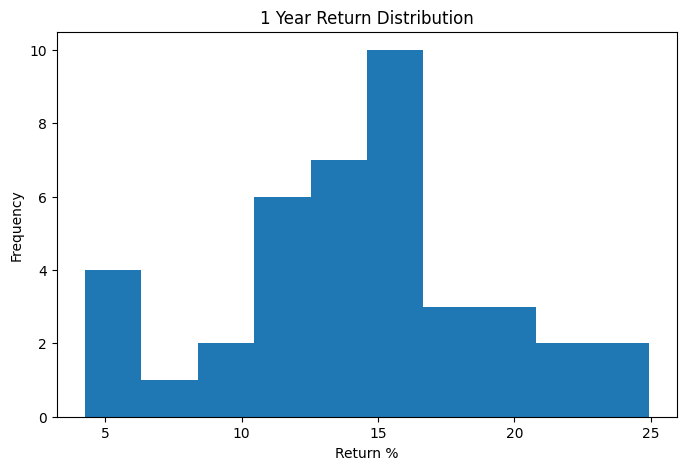

In [11]:
plt.figure(figsize=(8,5))
plt.hist(scheme_perf["return_1yr_pct"], bins=10)
plt.title("1 Year Return Distribution")
plt.xlabel("Return %")
plt.ylabel("Frequency")
plt.show()

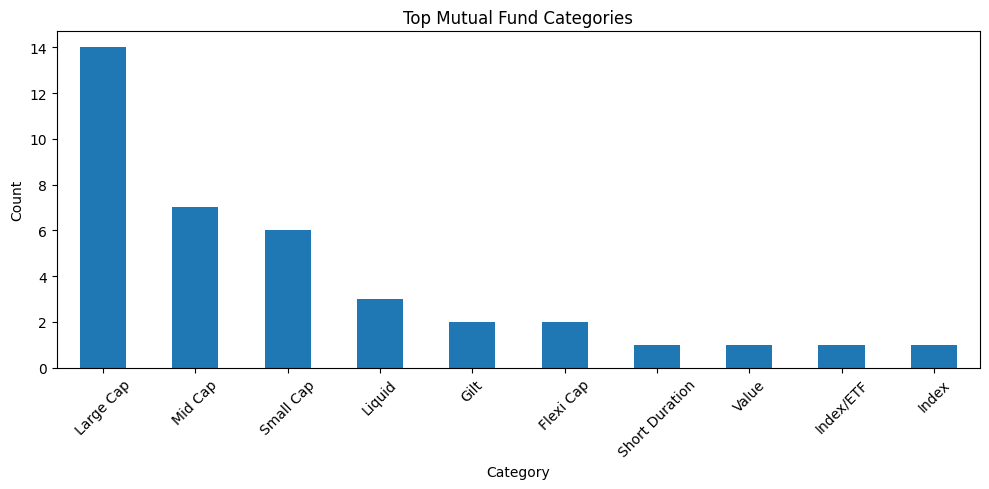

In [10]:
category_data = scheme_perf["category"].value_counts().head(10)

plt.figure(figsize=(10,5))
category_data.plot(kind="bar")
plt.title("Top Mutual Fund Categories")
plt.xlabel("Category")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

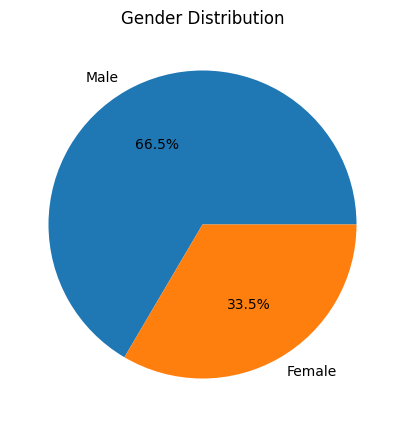

In [9]:
gender_data = investor_txn["gender"].value_counts()

plt.figure(figsize=(8,5))
gender_data.plot(kind="pie", autopct="%1.1f%%")
plt.title("Gender Distribution")
plt.ylabel("")
plt.show()

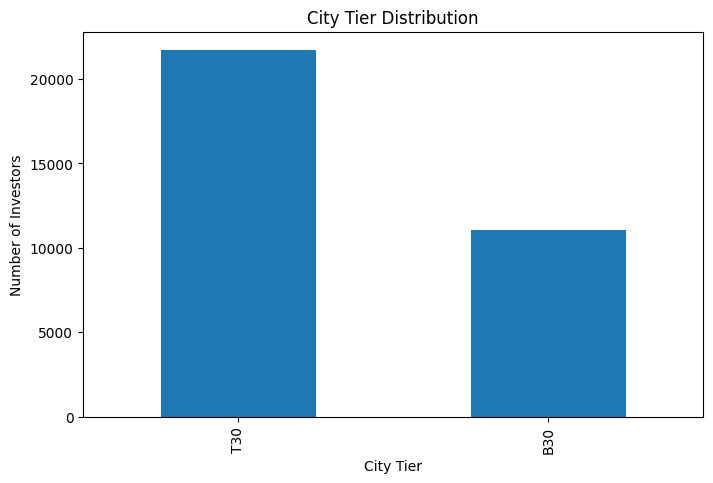

In [8]:
city_tier = investor_txn["city_tier"].value_counts()

plt.figure(figsize=(8,5))
city_tier.plot(kind="bar")
plt.title("City Tier Distribution")
plt.xlabel("City Tier")
plt.ylabel("Number of Investors")
plt.show()

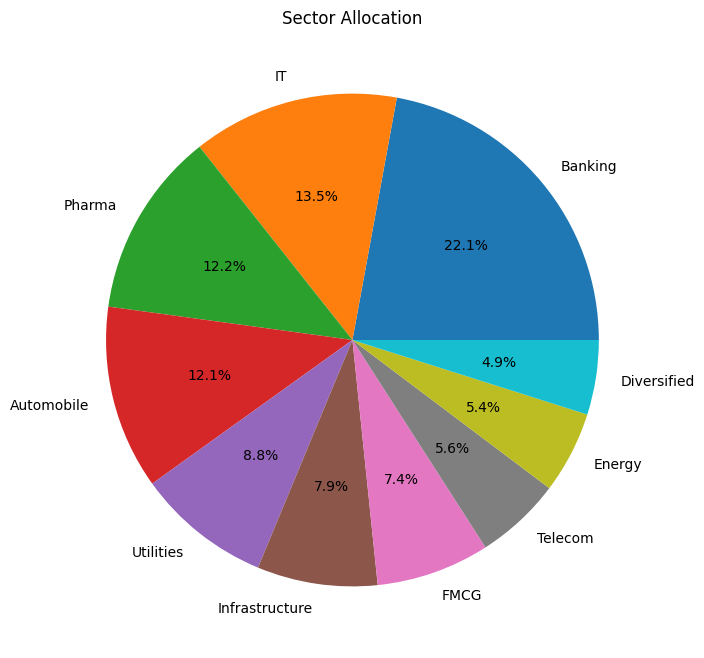

In [7]:
sector_data = (
    portfolio.groupby("sector")["market_value_cr"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(8,8))
sector_data.plot(kind="pie", autopct="%1.1f%%")
plt.title("Sector Allocation")
plt.ylabel("")
plt.show()

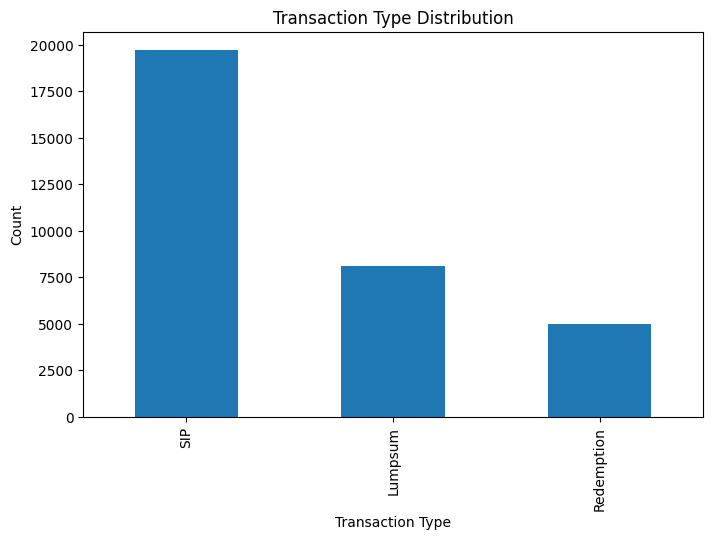

In [6]:
txn_type = investor_txn["transaction_type"].value_counts()

plt.figure(figsize=(8,5))
txn_type.plot(kind="bar")
plt.title("Transaction Type Distribution")
plt.xlabel("Transaction Type")
plt.ylabel("Count")
plt.show()

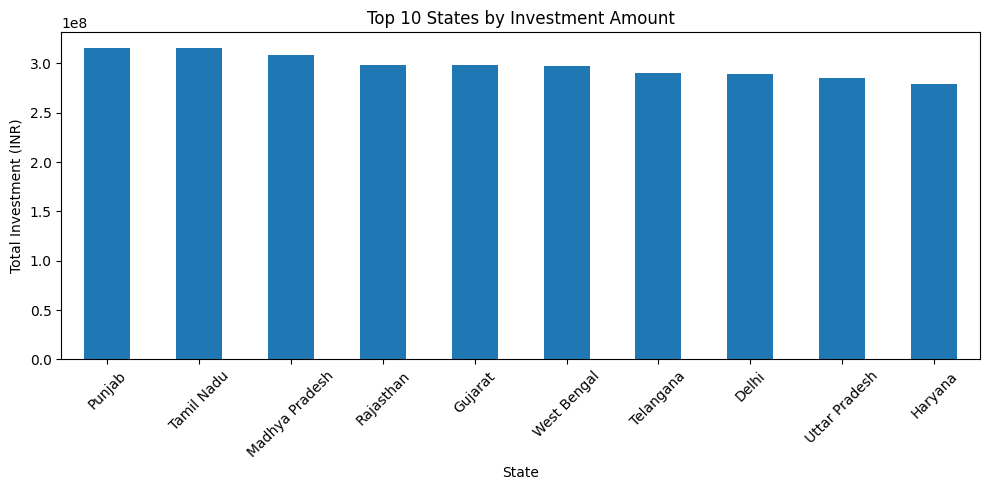

In [5]:
state_investment = (
    investor_txn.groupby("state")["amount_inr"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10,5))
state_investment.plot(kind="bar")
plt.title("Top 10 States by Investment Amount")
plt.xlabel("State")
plt.ylabel("Total Investment (INR)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

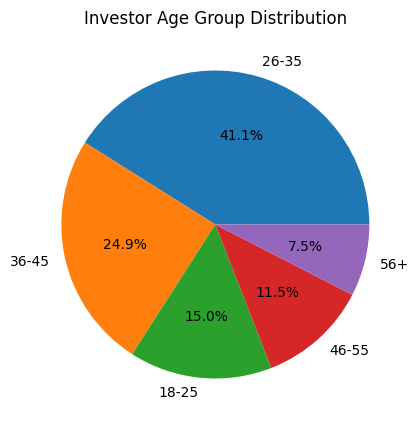

In [4]:
age_data = investor_txn["age_group"].value_counts()

plt.figure(figsize=(8,5))
age_data.plot(kind="pie", autopct="%1.1f%%")
plt.title("Investor Age Group Distribution")
plt.ylabel("")
plt.show()

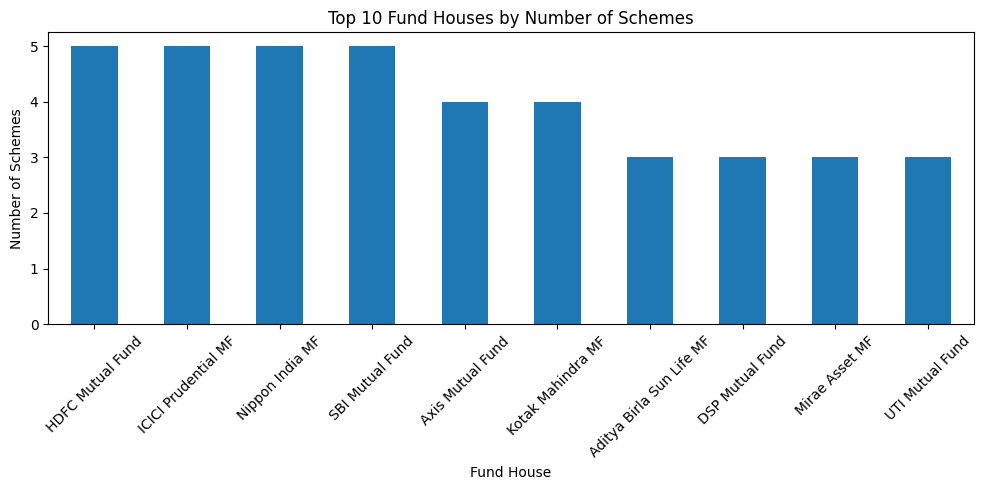

In [3]:
# Chart 1 - Top 10 Fund Houses

top_funds = (
    scheme_perf.groupby("fund_house")
    .size()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10,5))
top_funds.plot(kind="bar")
plt.title("Top 10 Fund Houses by Number of Schemes")
plt.xlabel("Fund House")
plt.ylabel("Number of Schemes")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [2]:
print("Scheme Performance Columns")
print(scheme_perf.columns.tolist())

print("\nInvestor Transactions Columns")
print(investor_txn.columns.tolist())

print("\nPortfolio Holdings Columns")
print(portfolio.columns.tolist())

print("\nBenchmark Columns")
print(benchmark.columns.tolist())

Scheme Performance Columns
['amfi_code', 'scheme_name', 'fund_house', 'category', 'plan', 'return_1yr_pct', 'return_3yr_pct', 'return_5yr_pct', 'benchmark_3yr_pct', 'alpha', 'beta', 'sharpe_ratio', 'sortino_ratio', 'std_dev_ann_pct', 'max_drawdown_pct', 'aum_crore', 'expense_ratio_pct', 'morningstar_rating', 'risk_grade']

Investor Transactions Columns
['investor_id', 'transaction_date', 'amfi_code', 'transaction_type', 'amount_inr', 'state', 'city', 'city_tier', 'age_group', 'gender', 'annual_income_lakh', 'payment_mode', 'kyc_status']

Portfolio Holdings Columns
['amfi_code', 'stock_symbol', 'stock_name', 'sector', 'weight_pct', 'market_value_cr', 'current_price_inr', 'portfolio_date']

Benchmark Columns
['date', 'index_name', 'close_value']


In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load datasets
scheme_perf = pd.read_csv("../data/raw/07_scheme_performance.csv")
investor_txn = pd.read_csv("../data/raw/08_investor_transactions.csv")
portfolio = pd.read_csv("../data/raw/09_portfolio_holdings.csv")
benchmark = pd.read_csv("../data/raw/10_benchmark_indices.csv")

print("Scheme Performance:", scheme_perf.shape)
print("Investor Transactions:", investor_txn.shape)
print("Portfolio Holdings:", portfolio.shape)
print("Benchmark Data:", benchmark.shape)

Scheme Performance: (40, 19)
Investor Transactions: (32778, 13)
Portfolio Holdings: (322, 8)
Benchmark Data: (8050, 3)


# Key EDA Findings

1. Banking sector has the highest portfolio allocation.
2. Nippon India MF has the highest AUM.
3. SIP inflows show a stable growth pattern.
4. Long-term returns are strongly correlated.
5. NAV trends indicate long-term market growth.
6. Benchmark indices show an upward trend.
7. Equity categories attract higher inflows.
8. Portfolio is diversified across sectors.
9. Fund houses differ significantly in AUM.
10. Risk-adjusted metrics vary among schemes.